# Credit Risk and Loan Repayment Analysis Using Python

## Project Overview
This project performs an end-to-end exploratory data analysis (EDA) on a credit loan dataset. The goal is to understand borrower characteristics, identify data quality issues, clean the dataset, and extract insights related to loan repayment and charge-off behavior.

## Key Questions
- What proportion of loans are fully paid versus charged off?
- Which borrower or loan attributes are associated with charge-offs?
- Are long-term loans riskier than short-term loans?
- How do credit score, income, debt burden, home ownership, and loan purpose relate to repayment behavior?
- Can feature engineering provide stronger financial risk indicators?

## Tools Used
Python, Pandas, NumPy, Matplotlib, and Seaborn.

## 1. Import Libraries
The required libraries are imported first. Display settings are adjusted to make the notebook easier to inspect.

In [43]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# File handling
from pathlib import Path

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Ignore warnings for cleaner notebook output
import warnings
warnings.filterwarnings('ignore')

# Visualization style
sns.set_style('whitegrid')

print('Libraries imported successfully!')

Libraries imported successfully!


## 2. Load the Dataset

In [44]:
from google.colab import files
uploaded = files.upload()

df = pd.read_csv('credit.csv')

df.head()

Saving credit.csv to credit (1).csv


,Loan ID,Customer ID,Loan Status,Current Loan Amount,Term,Credit Score,Annual Income,Years in current job,Home Ownership,Purpose,Monthly Debt,Years of Credit History,Months since last delinquent,Number of Open Accounts,Number of Credit Problems,Current Credit Balance,Maximum Open Credit,Bankruptcies,Tax Liens
0,14dd8831-6af5-400b-83ec-68e61888a048,981165ec-3274-42f5-a3b4-d104041a9ca9,Fully Paid,445412,Short Term,709.0,1167493.0,8 years,Home Mortgage,Home Improvements,5214.74,17.2,NaN,6,1,228190,416746.0,1.0,0.0
1,4771cc26-131a-45db-b5aa-537ea4ba5342,2de017a3-2e01-49cb-a581-08169e83be29,Fully Paid,262328,Short Term,NaN,NaN,10+ years,Home Mortgage,Debt Consolidation,33295.98,21.1,8.0,35,0,229976,850784.0,0.0,0.0
2,4eed4e6a-aa2f-4c91-8651-ce984ee8fb26,5efb2b2b-bf11-4dfd-a572-3761a2694725,Fully Paid,99999999,Short Term,741.0,2231892.0,8 years,Own Home,Debt Consolidation,29200.53,14.9,29.0,18,1,297996,750090.0,0.0,0.0
3,77598f7b-32e7-4e3b-a6e5-06ba0d98fe8a,e777faab-98ae-45af-9a86-7ce5b33b1011,Fully Paid,347666,Long Term,721.0,806949.0,3 years,Own Home,Debt Consolidation,8741.90,12.0,NaN,9,0,256329,386958.0,0.0,0.0
4,d4062e70-befa-4995-8643-a0de73938182,81536ad9-5ccf-4eb8-befb-47a4d608658e,Fully Paid,176220,Short Term,NaN,NaN,5 years,Rent,Debt Consolidation,20639.70,6.1,NaN,15,0,253460,427174.0,0.0,0.0


## 3. Dataset Overview
This section checks the dataset size, column names, data types, and summary statistics. It helps identify early issues such as missing values, incorrect data types, and suspicious numerical ranges.

In [45]:
print('Dataset Shape:', df.shape)
print('\nColumns:')
print(df.columns.tolist())

Dataset Shape: (100000, 19)

Columns:
['Loan ID', 'Customer ID', 'Loan Status', 'Current Loan Amount', 'Term', 'Credit Score', 'Annual Income', 'Years in current job', 'Home Ownership', 'Purpose', 'Monthly Debt', 'Years of Credit History', 'Months since last delinquent', 'Number of Open Accounts', 'Number of Credit Problems', 'Current Credit Balance', 'Maximum Open Credit', 'Bankruptcies', 'Tax Liens']


In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 19 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   Loan ID                       100000 non-null  object 
 1   Customer ID                   100000 non-null  object 
 2   Loan Status                   100000 non-null  object 
 3   Current Loan Amount           100000 non-null  int64  
 4   Term                          100000 non-null  object 
 5   Credit Score                  80846 non-null   float64
 6   Annual Income                 80846 non-null   float64
 7   Years in current job          95778 non-null   object 
 8   Home Ownership                100000 non-null  object 
 9   Purpose                       100000 non-null  object 
 10  Monthly Debt                  100000 non-null  float64
 11  Years of Credit History       100000 non-null  float64
 12  Months since last delinquent  46859 non-null 

In [47]:
df.describe()

,Current Loan Amount,Credit Score,Annual Income,Monthly Debt,Years of Credit History,Months since last delinquent,Number of Open Accounts,Number of Credit Problems,Current Credit Balance,Maximum Open Credit,Bankruptcies,Tax Liens
count,1.000000e+05,80846.000000,8.084600e+04,100000.000000,100000.000000,46859.000000,100000.00000,100000.000000,1.000000e+05,9.999800e+04,99796.000000,99990.000000
mean,1.176045e+07,1076.456089,1.378277e+06,18472.412336,18.199141,34.901321,11.12853,0.168310,2.946374e+05,7.607984e+05,0.117740,0.029313
std,3.178394e+07,1475.403791,1.081360e+06,12174.992609,7.015324,21.997829,5.00987,0.482705,3.761709e+05,8.384503e+06,0.351424,0.258182
min,1.080200e+04,585.000000,7.662700e+04,0.000000,3.600000,0.000000,0.00000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000
25%,1.796520e+05,705.000000,8.488440e+05,10214.162500,13.500000,16.000000,8.00000,0.000000,1.126700e+05,2.734380e+05,0.000000,0.000000
50%,3.122460e+05,724.000000,1.174162e+06,16220.300000,16.900000,32.000000,10.00000,0.000000,2.098170e+05,4.678740e+05,0.000000,0.000000
75%,5.249420e+05,741.000000,1.650663e+06,24012.057500,21.700000,51.000000,14.00000,0.000000,3.679588e+05,7.829580e+05,0.000000,0.000000
max,1.000000e+08,7510.000000,1.655574e+08,435843.280000,70.500000,176.000000,76.00000,15.000000,3.287897e+07,1.539738e+09,7.000000,15.000000


### Initial Observations
The dataset contains loan-level information, borrower financial attributes, and the target outcome `Loan Status`. Early inspection shows missing values in important financial columns and suspicious values in `Current Loan Amount` and `Credit Score`, which require further investigation.

## 4. Data Quality Assessment
Before cleaning, the dataset is assessed for missing values, duplicates, categorical inconsistencies, and suspicious placeholder values.

In [48]:
# Missing value summary
missing_values = df.isnull().sum()
missing_percentage = (missing_values / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Values': missing_values,
    'Percentage (%)': missing_percentage
}).sort_values(by='Percentage (%)', ascending=False)

missing_df

,Missing Values,Percentage (%)
Months since last delinquent,53141,53.141
Annual Income,19154,19.154
Credit Score,19154,19.154
Years in current job,4222,4.222
Bankruptcies,204,0.204
Tax Liens,10,0.010
Maximum Open Credit,2,0.002
Loan Status,0,0.000
Customer ID,0,0.000
Loan ID,0,0.000


In [49]:
# Check exact duplicate rows
duplicates = df.duplicated().sum()
print('Number of duplicate rows:', duplicates)

Number of duplicate rows: 10215


In [50]:
# Check categorical columns for inconsistent labels
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    print(f'\n{col}')
    print(df[col].value_counts())


Loan ID
Loan ID
cdf2f31f-f04e-45f9-9ce2-2399235cd6fb    2
0c14cb77-29a3-4964-9198-0c43f5f982b0    2
578c8e10-3214-4491-bdbc-b1695ef8ff87    2
7aa649ff-b73b-4556-a4c3-a4d35762809a    2
24e8c8bd-d10b-4dac-8b81-1da470ff5ecb    2
                                       ..
2a0c450f-44ff-4014-a319-ef59e17ea5d5    1
40617302-5cb1-4db8-9867-ade39c1751dc    1
2ff2c5d0-bf24-4241-a9b4-8eeaff8724ab    1
604de9e3-1cef-41ff-a334-8f798c2ddd19    1
0ee71c4c-10ca-4849-b437-314317022f62    1
Name: count, Length: 81999, dtype: int64

Customer ID
Customer ID
56a0ba34-abcd-413a-8c82-0fc0404bec6f    2
9baf6d5d-f744-4332-abb0-e939b75cde40    2
cbe53e22-ba67-4eaf-a4fb-c5acdd12ec66    2
54f57722-2473-4dd8-b69b-82b5b0c1c9f9    2
967e8733-7189-49b7-a3ab-6a1d0e1abdac    2
                                       ..
8583fc23-bf8d-434b-b33d-1c8152e3e254    1
f423f0f1-ee1c-4cca-ab91-b8c349b24fcf    1
4ec8ccaf-9aeb-45b7-aa58-b46f9c3dac2e    1
4b5fda6f-cbe5-46a1-b167-fc31d87d0d72    1
05979eaa-82f7-4909-8cbb-548bd44d1b0

In [51]:
# Inspect suspicious current loan amount values
df['Current Loan Amount'].value_counts().head(10)

,count
Current Loan Amount,
99999999,11484
223652,27
223102,27
223322,27
216194,27
222596,26
108966,26
214962,25
216810,25


In [52]:
# Check duplicated loan identifiers
loan_duplicates = df['Loan ID'].duplicated().sum()
print('Duplicate Loan IDs:', loan_duplicates)

# View examples of duplicated loan IDs
df[df['Loan ID'].duplicated(keep=False)].head(10)

Duplicate Loan IDs: 18001


,Loan ID,Customer ID,Loan Status,Current Loan Amount,Term,Credit Score,Annual Income,Years in current job,Home Ownership,Purpose,Monthly Debt,Years of Credit History,Months since last delinquent,Number of Open Accounts,Number of Credit Problems,Current Credit Balance,Maximum Open Credit,Bankruptcies,Tax Liens
0,14dd8831-6af5-400b-83ec-68e61888a048,981165ec-3274-42f5-a3b4-d104041a9ca9,Fully Paid,445412,Short Term,709.0,1167493.0,8 years,Home Mortgage,Home Improvements,5214.74,17.2,NaN,6,1,228190,416746.0,1.0,0.0
3,77598f7b-32e7-4e3b-a6e5-06ba0d98fe8a,e777faab-98ae-45af-9a86-7ce5b33b1011,Fully Paid,347666,Long Term,721.0,806949.0,3 years,Own Home,Debt Consolidation,8741.90,12.0,NaN,9,0,256329,386958.0,0.0,0.0
4,d4062e70-befa-4995-8643-a0de73938182,81536ad9-5ccf-4eb8-befb-47a4d608658e,Fully Paid,176220,Short Term,NaN,NaN,5 years,Rent,Debt Consolidation,20639.70,6.1,NaN,15,0,253460,427174.0,0.0,0.0
8,8af915d9-9e91-44a0-b5a2-564a45c12089,af534dea-d27e-4fd6-9de8-efaa52a78ec0,Fully Paid,548746,Short Term,678.0,2559110.0,2 years,Rent,Debt Consolidation,18660.28,22.6,33.0,4,0,437171,555038.0,0.0,0.0
15,7cbaa3fa-16fd-4343-9bcb-e90b34a1072f,3ec886e7-f15d-4c35-83d0-bdec4817ae4b,Fully Paid,449020,Long Term,NaN,NaN,9 years,Own Home,Debt Consolidation,18904.81,19.4,NaN,8,0,334533,428956.0,0.0,0.0
17,24e8c8bd-d10b-4dac-8b81-1da470ff5ecb,967e8733-7189-49b7-a3ab-6a1d0e1abdac,Fully Paid,666204,Long Term,723.0,1821967.0,10+ years,Home Mortgage,Debt Consolidation,17612.24,22.0,34.0,15,0,813694,2004618.0,0.0,0.0
24,7aa649ff-b73b-4556-a4c3-a4d35762809a,54f57722-2473-4dd8-b69b-82b5b0c1c9f9,Fully Paid,244926,Long Term,704.0,1249953.0,4 years,Home Mortgage,Debt Consolidation,6812.26,14.4,NaN,6,1,143051,245014.0,0.0,1.0
25,578c8e10-3214-4491-bdbc-b1695ef8ff87,cbe53e22-ba67-4eaf-a4fb-c5acdd12ec66,Fully Paid,465410,Long Term,688.0,1722654.0,3 years,Rent,Buy House,15647.45,22.3,30.0,7,0,107559,488356.0,0.0,0.0
26,0c14cb77-29a3-4964-9198-0c43f5f982b0,9baf6d5d-f744-4332-abb0-e939b75cde40,Fully Paid,99999999,Short Term,724.0,1029857.0,1 year,Rent,Debt Consolidation,13817.18,12.0,NaN,6,0,138339,221232.0,0.0,0.0
33,af76ed30-e663-4125-8749-3ff5e509cb37,61a4f1ed-e2c3-401e-aec8-9b0d7178f5ff,Fully Paid,333564,Long Term,725.0,1248338.0,10+ years,Home Mortgage,Debt Consolidation,18205.04,14.6,NaN,18,0,300979,515526.0,0.0,0.0


### Data Quality Findings
- The dataset contains exact duplicate rows that should be removed.
- `Current Loan Amount` contains the placeholder value `99999999`, which is not a realistic loan amount.
- Some `Credit Score` values are above the usual credit score range and appear to be scaled by a factor of 10.
- `Home Ownership` contains inconsistent categories such as `HaveMortgage` and `Home Mortgage`.
- `Purpose` contains inconsistent capitalization, such as `Other` and `other`.
- `Months since last delinquent` has many missing values. These are intentionally preserved because missingness likely represents no recorded delinquency history rather than ordinary missing data.

## 5. Outlier and Anomaly Inspection
Boxplots are used to visually inspect suspicious numerical features before cleaning decisions are made.

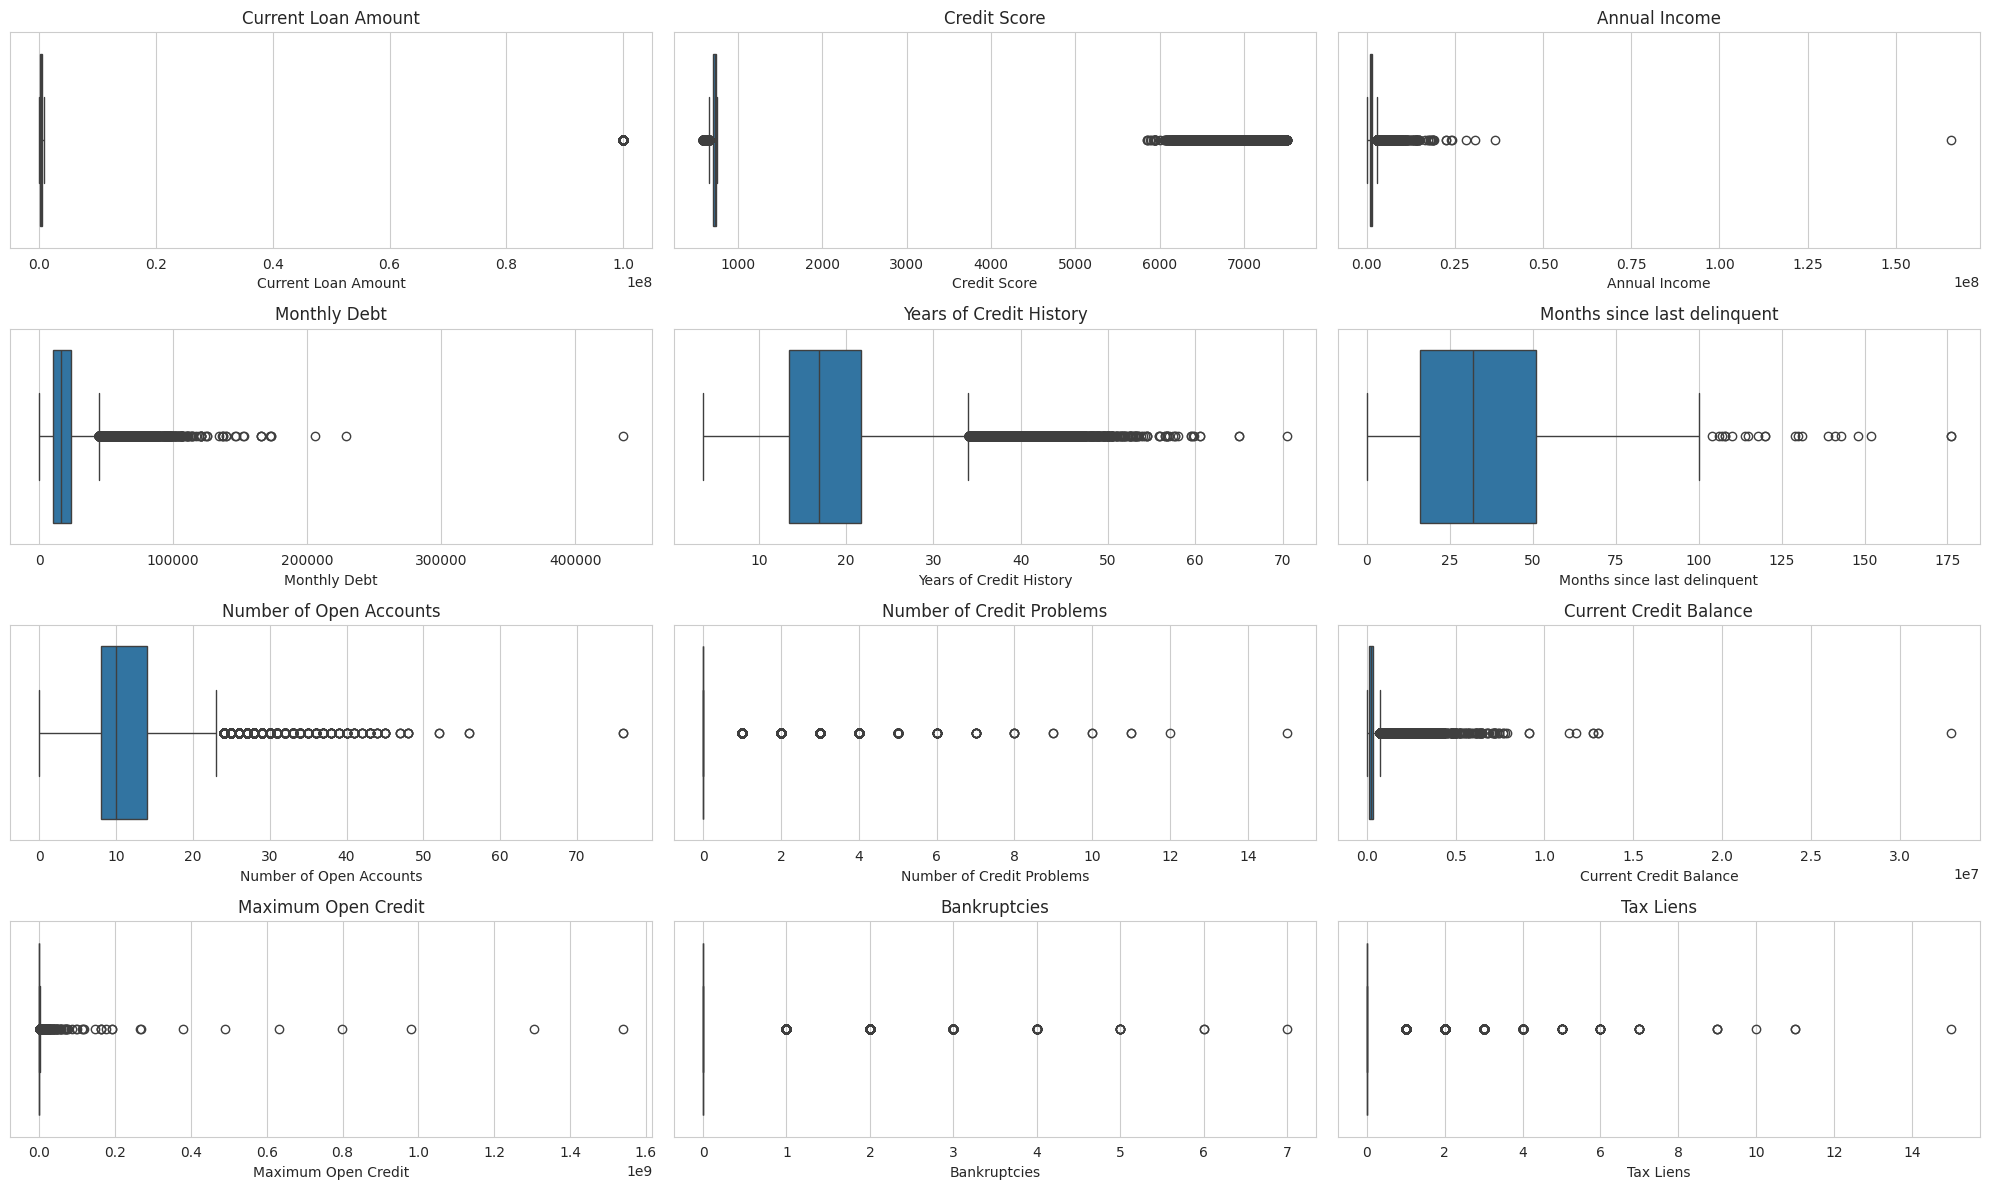

In [53]:
# Numerical columns
numerical_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(20, 12))

for i, col in enumerate(numerical_cols, 1):
    plt.subplot(4, 3, i)
    sns.boxplot(x=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [54]:
# Inspect credit score range and high values
display(df['Credit Score'].describe())
display(df['Credit Score'].sort_values(ascending=False).head(20))

# Count placeholder loan amount values
placeholder_count = (df['Current Loan Amount'] == 99999999).sum()
print('Number of placeholder loan amounts:', placeholder_count)

,Credit Score
count,80846.000000
mean,1076.456089
std,1475.403791
min,585.000000
25%,705.000000
50%,724.000000
75%,741.000000
max,7510.000000


,Credit Score
57290,7510.0
23322,7510.0
27919,7510.0
76476,7510.0
43351,7510.0
83211,7510.0
3748,7510.0
24068,7510.0
64774,7510.0
57521,7500.0


Number of placeholder loan amounts: 11484


### Anomaly Findings
Credit scores above 850 appear to be incorrectly scaled. For example, values such as 7510 likely represent 751.0. The loan amount value `99999999` is treated as a placeholder for missing or unknown values.

## 6. Data Cleaning
A copy of the dataset is created before applying cleaning operations. This preserves the original raw data.

In [55]:
# Create working copy
df_clean = df.copy()
print('Copy created successfully!')

Copy created successfully!


In [56]:
# Remove exact duplicate rows
df_clean.drop_duplicates(inplace=True)

print('Shape after removing duplicates:')
print(df_clean.shape)

Shape after removing duplicates:
(89785, 19)


In [57]:
# Fix wrongly scaled credit scores
# Values above 850 are divided by 10 based on the observed scaling issue.
df_clean['Credit Score'] = df_clean['Credit Score'].apply(
    lambda x: x / 10 if pd.notnull(x) and x > 850 else x
)

df_clean['Credit Score'].describe()

,Credit Score
count,70631.000000
mean,718.579476
std,28.126929
min,585.000000
25%,706.000000
50%,725.000000
75%,740.000000
max,751.000000


In [58]:
# Replace placeholder loan amount with NaN
df_clean['Current Loan Amount'] = df_clean[
    'Current Loan Amount'
    ].replace(99999999, np.nan)

print('Missing loan amounts after placeholder replacement:', df_clean['Current Loan Amount'].isnull().sum())

Missing loan amounts after placeholder replacement: 11484


In [59]:
# Standardize home ownership categories
df_clean['Home Ownership'] = df_clean['Home Ownership'].replace('HaveMortgage', 'Home Mortgage')

df_clean['Home Ownership'].value_counts()

,count
Home Ownership,
Home Mortgage,43731
Rent,37855
Own Home,8199


In [60]:
# Standardize purpose labels
# Lowercasing merges categories such as Other and other.
df_clean['Purpose'] = df_clean['Purpose'].str.lower()

df_clean['Purpose'].value_counts()

,count
Purpose,
debt consolidation,70834
other,8117
home improvements,5237
business loan,1366
buy a car,1165
medical bills,983
buy house,582
take a trip,488
major_purchase,330


In [61]:
# Missing values after initial cleaning
missing_values = df_clean.isnull().sum()
missing_percentage = (missing_values / len(df_clean)) * 100

missing_summary = pd.DataFrame({
    'Missing Values': missing_values,
    'Percentage (%)': missing_percentage
}).sort_values(by='Percentage (%)', ascending=False)

missing_summary

,Missing Values,Percentage (%)
Months since last delinquent,48337,53.836387
Annual Income,19154,21.333185
Credit Score,19154,21.333185
Current Loan Amount,11484,12.790555
Years in current job,3802,4.234560
Bankruptcies,190,0.211617
Tax Liens,9,0.010024
Maximum Open Credit,2,0.002228
Loan Status,0,0.000000
Loan ID,0,0.000000


## 7. Missing Value Treatment
Median imputation is used for skewed numerical variables because these features contain outliers. Mode imputation is used for `Years in current job` before converting it into numeric format.

`Months since last delinquent` is **not imputed** because its missing values are analytically meaningful. In this context, missing values likely indicate no recorded delinquency history, while a value of 0 means a very recent delinquency. Replacing missing values with 0 would mix two different meanings.

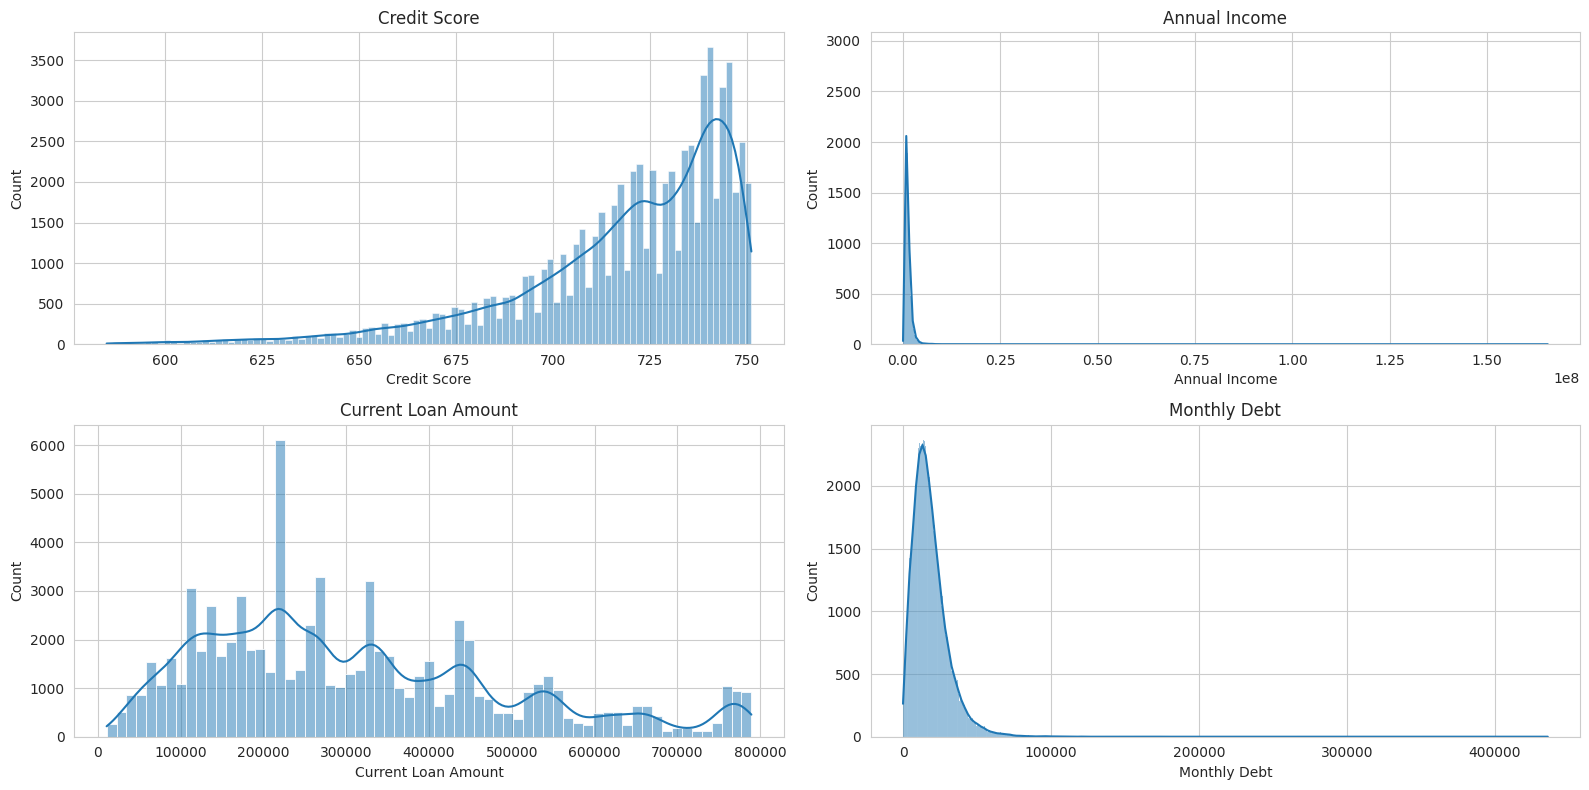

In [62]:
# Visualize selected distributions before imputation
important_cols = [
    'Credit Score',
    'Annual Income',
    'Current Loan Amount',
    'Monthly Debt'
]

plt.figure(figsize=(16, 8))

for i, col in enumerate(important_cols, 1):
    plt.subplot(2, 2, i)
    sns.histplot(df_clean[col], kde=True, color='C0')
    plt.title(col)

plt.tight_layout()
plt.show()

In [63]:
# Median imputation for selected numerical columns
median_cols = [
    'Credit Score',
    'Annual Income',
    'Current Loan Amount',
    'Bankruptcies',
    'Tax Liens',
    'Maximum Open Credit'
]

for col in median_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# Mode imputation for years in current job before conversion

df_clean['Years in current job'] = df_clean['Years in current job'].fillna(
    df_clean['Years in current job'].mode()[0]
)

print('Selected missing values treated successfully!')

Selected missing values treated successfully!


In [64]:
# Delinquency column is intentionally preserved with missing values
df_clean['Months since last delinquent'].describe()

,Months since last delinquent
count,41448.000000
mean,34.975873
std,22.008585
min,0.000000
25%,16.000000
50%,32.000000
75%,51.000000
max,176.000000


In [65]:
# Confirm remaining missing values
# Only Months since last delinquent should remain missing.
df_clean.isnull().sum()

,0
Loan ID,0
Customer ID,0
Loan Status,0
Current Loan Amount,0
Term,0
Credit Score,0
Annual Income,0
Years in current job,0
Home Ownership,0
Purpose,0


In [66]:
# Convert Years in current job into numeric format
# 10+ years - 10, < 1 year - 0.5

df_clean['Years in current job'] = (
    df_clean['Years in current job']
    .str.replace('+', '', regex=False)
    .str.replace(' years', '', regex=False)
    .str.replace(' year', '', regex=False)
    .str.replace('< 1', '0.5', regex=False)
)

df_clean['Years in current job'] = pd.to_numeric(df_clean['Years in current job'])

df_clean['Years in current job'].describe()

,Years in current job
count,89785.000000
mean,6.091792
std,3.582690
min,0.500000
25%,3.000000
50%,6.000000
75%,10.000000
max,10.000000


### Cleaning Summary
The dataset is now suitable for EDA. Exact duplicates were removed, invalid credit scores were corrected, placeholder loan amounts were handled, categorical labels were standardized, and selected missing values were treated using defensible methods.

## 8. Univariate Analysis
This section examines individual variables to understand the dataset population and general borrowing patterns.

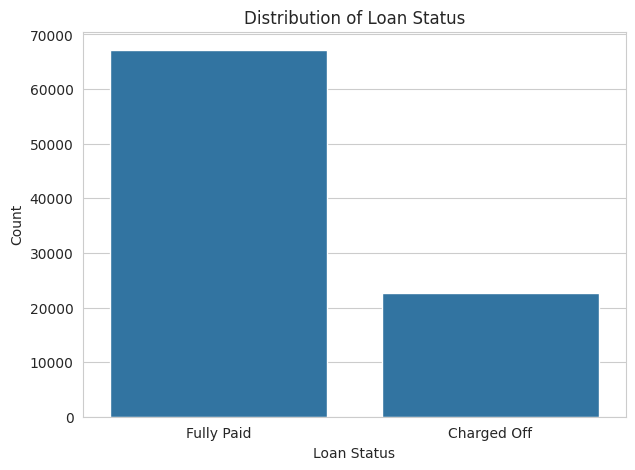

,proportion
Loan Status,
Fully Paid,74.78532
Charged Off,25.21468


In [67]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df_clean, x='Loan Status', color='C0')
plt.title('Distribution of Loan Status')
plt.xlabel('Loan Status')
plt.ylabel('Count')
plt.show()

loan_status_pct = df_clean['Loan Status'].value_counts(normalize=True) * 100
loan_status_pct

**Insight:** Most loans were fully paid, but charged-off loans still account for roughly one-quarter of the dataset. This indicates that repayment risk is meaningful and worth investigating further.

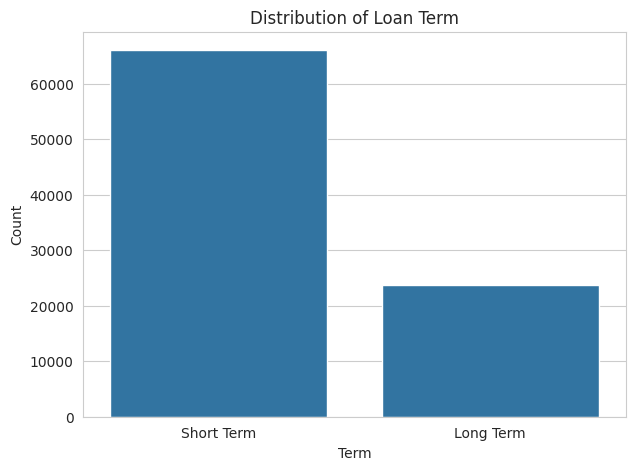

,proportion
Term,
Short Term,73.534555
Long Term,26.465445


In [68]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df_clean, x='Term', color='C0')
plt.title('Distribution of Loan Term')
plt.xlabel('Term')
plt.ylabel('Count')
plt.show()

df_clean['Term'].value_counts(normalize=True) * 100

**Insight:** Short-term loans dominate the portfolio, suggesting that most borrowers prefer shorter repayment durations or that lenders issue more short-term products.

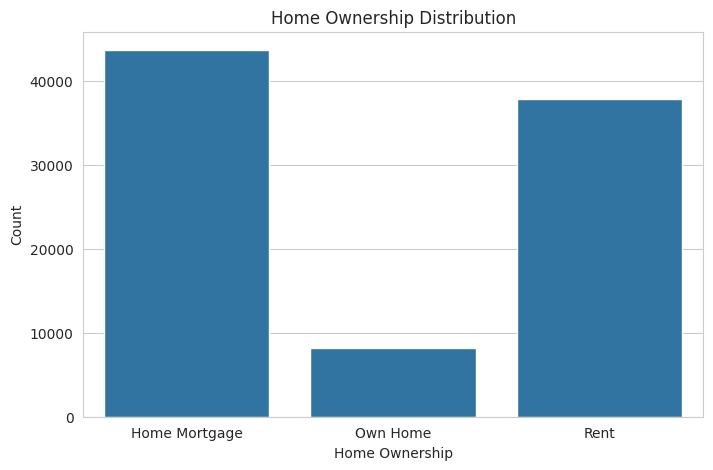

In [69]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df_clean, x='Home Ownership', color='C0')
plt.title('Home Ownership Distribution')
plt.xlabel('Home Ownership')
plt.ylabel('Count')
plt.show()

**Insight:** Borrowers with mortgages and renters form the largest groups, while outright homeowners represent a smaller share of the dataset.

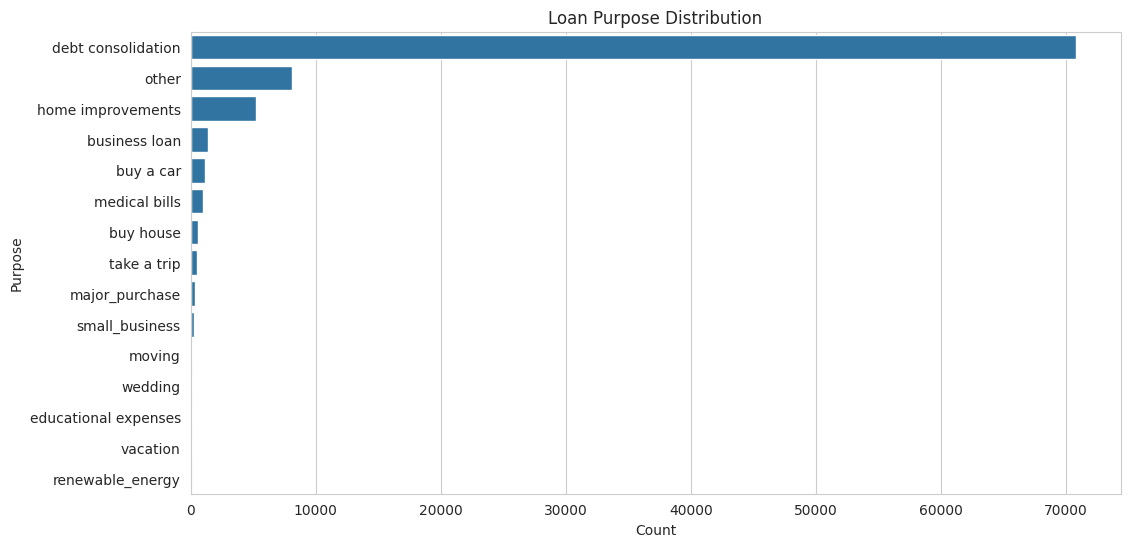

,proportion
Purpose,
debt consolidation,78.893
other,9.040
home improvements,5.833
business loan,1.521
buy a car,1.298
medical bills,1.095
buy house,0.648
take a trip,0.544
major_purchase,0.368


In [70]:
plt.figure(figsize=(12, 6))

purpose_counts = df_clean['Purpose'].value_counts()
sns.barplot(y=purpose_counts.index, x=purpose_counts.values, color='C0')

plt.title('Loan Purpose Distribution')
plt.xlabel('Count')
plt.ylabel('Purpose')
plt.show()

# Percentage breakdown
(df_clean['Purpose'].value_counts(normalize=True) * 100).round(3)

**Insight:** Debt consolidation overwhelmingly dominates loan purpose, suggesting that most borrowers use loans to restructure or manage existing debt rather than finance new consumption.

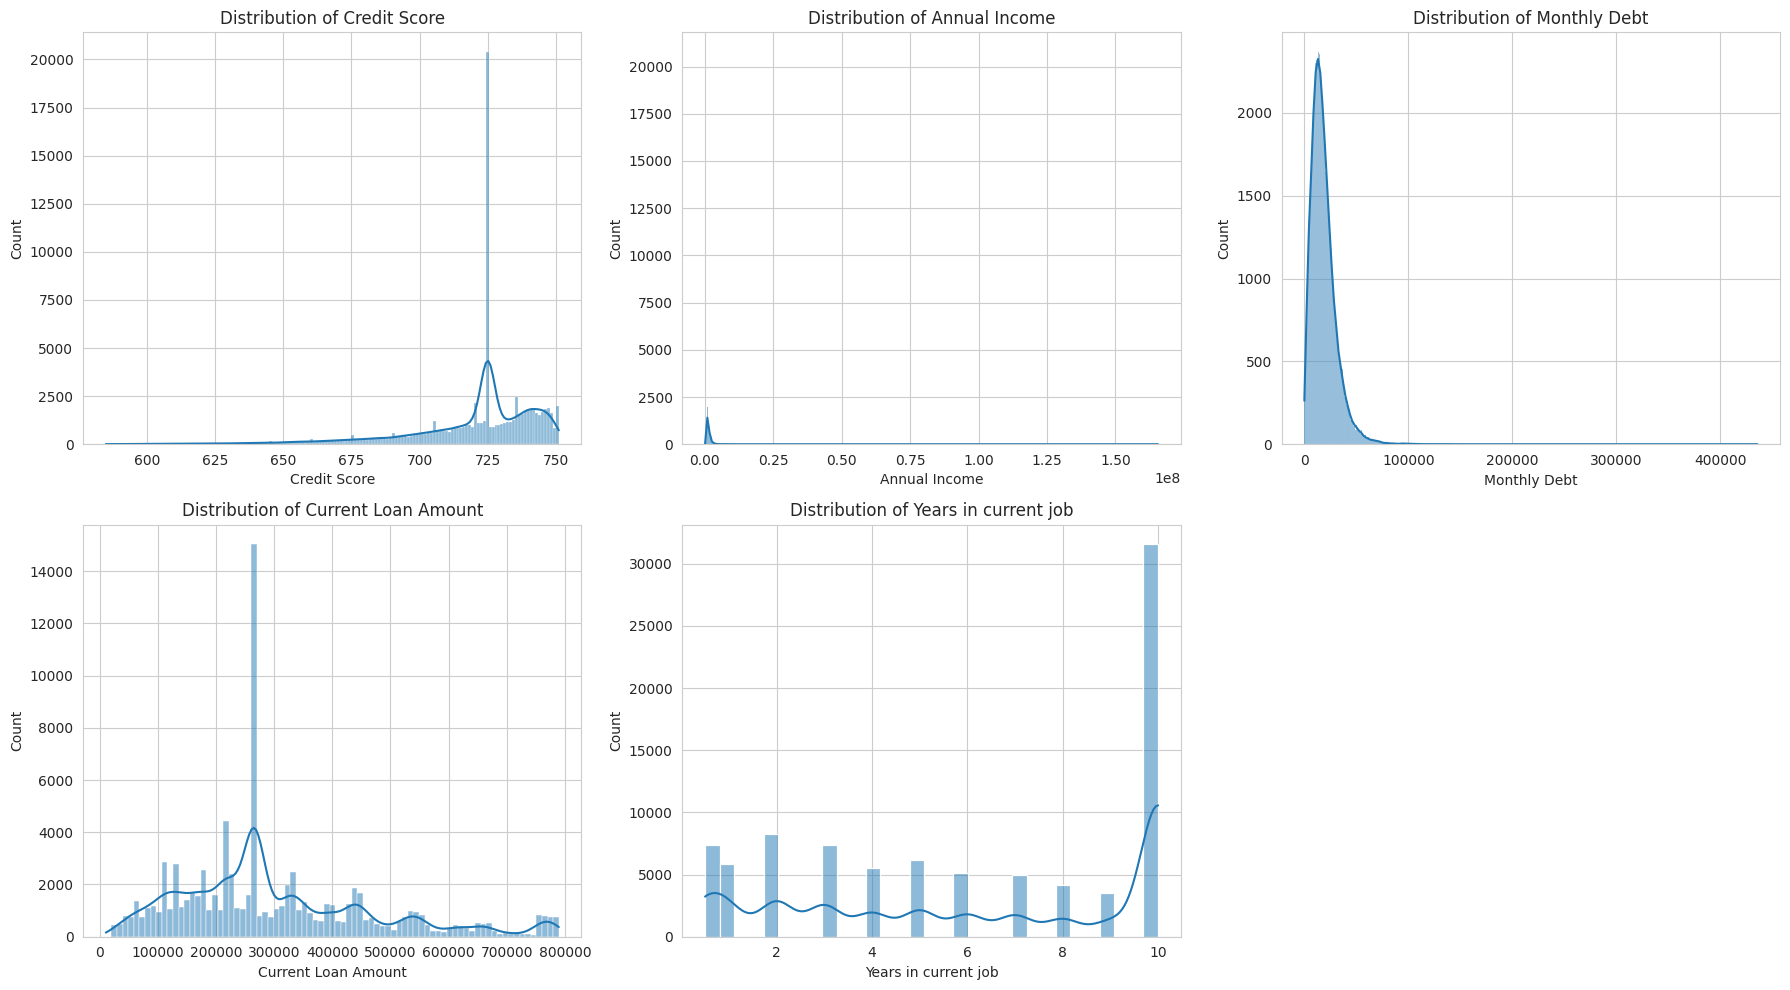

In [71]:
num_cols = [
    'Credit Score',
    'Annual Income',
    'Monthly Debt',
    'Current Loan Amount',
    'Years in current job'
]

plt.figure(figsize=(18, 10))

for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 3, i)
    sns.histplot(df_clean[col], kde=True, color='C0')
    plt.title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

**Insight:** Credit scores are concentrated in the higher range, while income and monthly debt are strongly right-skewed. Loan amounts appear clustered around common lending bands, and many borrowers report long employment tenure.

## 9. Bivariate Analysis
This section compares key variables against `Loan Status` to identify patterns associated with full repayment and charge-offs.

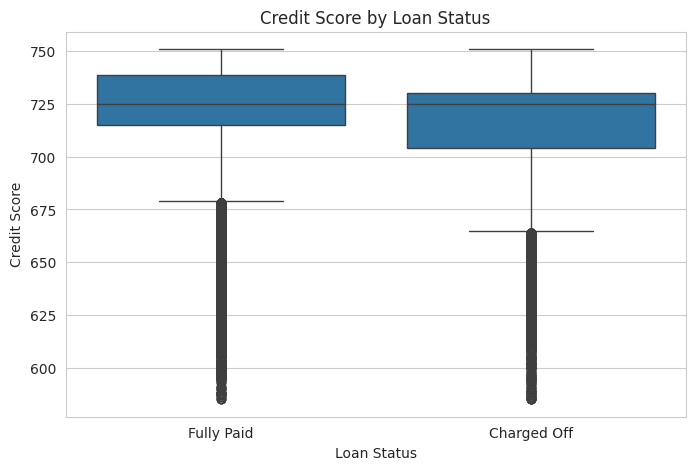

In [72]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_clean, x='Loan Status', y='Credit Score')
plt.title('Credit Score by Loan Status')
plt.show()

**Insight:** Fully paid loans generally show slightly higher credit scores than charged-off loans. This suggests creditworthiness is associated with repayment outcome, although the difference is moderate.

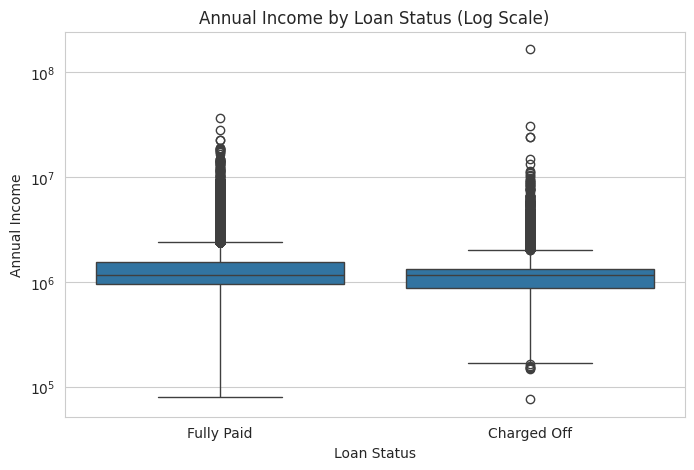

In [73]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_clean, x='Loan Status', y='Annual Income')
plt.yscale('log')
plt.title('Annual Income by Loan Status (Log Scale)')
plt.show()

**Insight:** Annual income is highly skewed, so a log scale provides a clearer comparison. Fully paid borrowers show a slightly higher income distribution, although income alone does not fully explain repayment behavior.

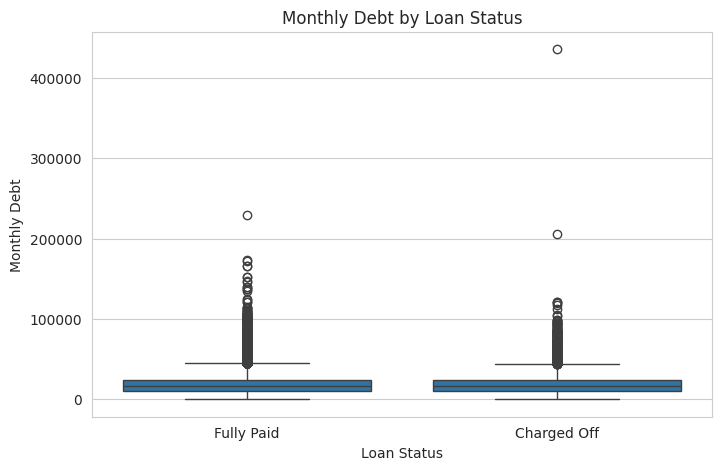

In [74]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_clean, x='Loan Status', y='Monthly Debt')
plt.title('Monthly Debt by Loan Status')
plt.show()

**Insight:** Charged-off borrowers tend to show slightly higher monthly debt and more extreme debt values, suggesting debt burden may contribute to repayment difficulty.

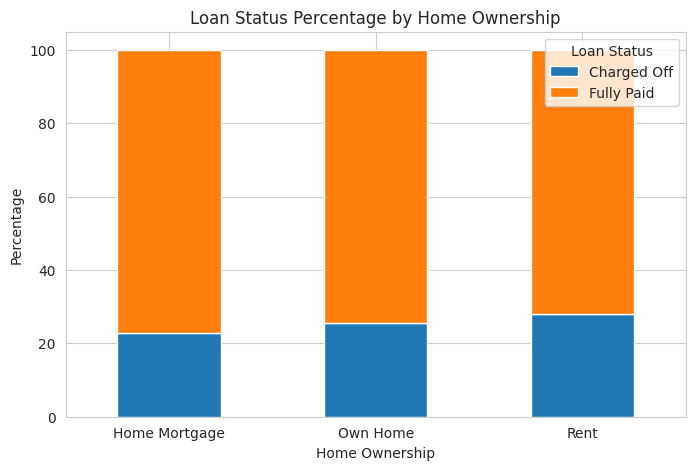

Loan Status,Charged Off,Fully Paid
Home Ownership,,
Home Mortgage,22.73,77.27
Own Home,25.64,74.36
Rent,27.99,72.01


In [75]:
home_status = pd.crosstab(
    df_clean['Home Ownership'],
    df_clean['Loan Status'],
    normalize='index'
) * 100

home_status.plot(kind='bar', stacked=True, figsize=(8, 5))
plt.title('Loan Status Percentage by Home Ownership')
plt.ylabel('Percentage')
plt.xlabel('Home Ownership')
plt.xticks(rotation=0)
plt.show()

home_status.round(2)

**Insight:** Renters show a slightly higher charge-off proportion than mortgage holders and homeowners, suggesting housing stability may be related to repayment risk.

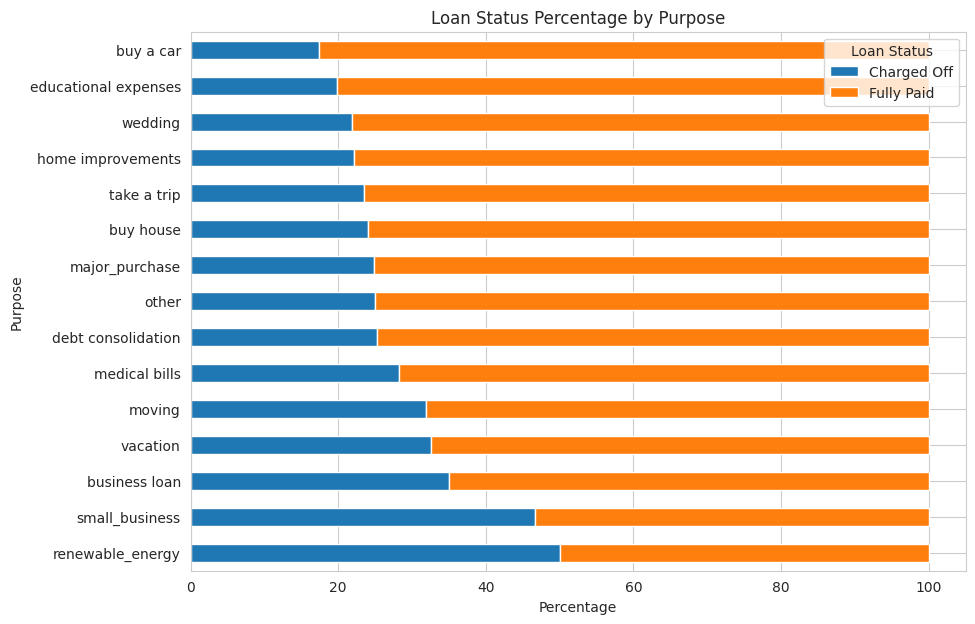

Loan Status,Charged Off,Fully Paid
Purpose,,
renewable_energy,50.00,50.00
small_business,46.67,53.33
business loan,34.99,65.01
vacation,32.58,67.42
moving,31.85,68.15
medical bills,28.28,71.72
debt consolidation,25.30,74.70
other,24.96,75.04
major_purchase,24.85,75.15


In [76]:
purpose_status = pd.crosstab(
    df_clean['Purpose'],
    df_clean['Loan Status'],
    normalize='index'
) * 100

purpose_status = purpose_status.sort_values(by='Charged Off', ascending=False)

purpose_status.plot(kind='barh', stacked=True, figsize=(10, 7))
plt.title('Loan Status Percentage by Purpose')
plt.xlabel('Percentage')
plt.ylabel('Purpose')
plt.show()

purpose_status.round(2)

**Insight:** Some purposes, such as small business, business loan, and renewable energy, show higher charge-off proportions. However, categories with small sample sizes should be interpreted cautiously.

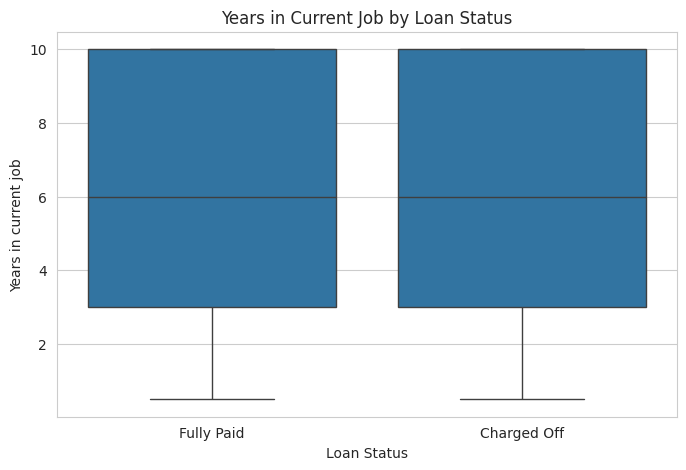

In [77]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_clean, x='Loan Status', y='Years in current job')
plt.title('Years in Current Job by Loan Status')
plt.show()

**Insight:** Employment duration is very similar between fully paid and charged-off loans, suggesting that job tenure alone is not a strong differentiator of repayment outcome in this dataset.

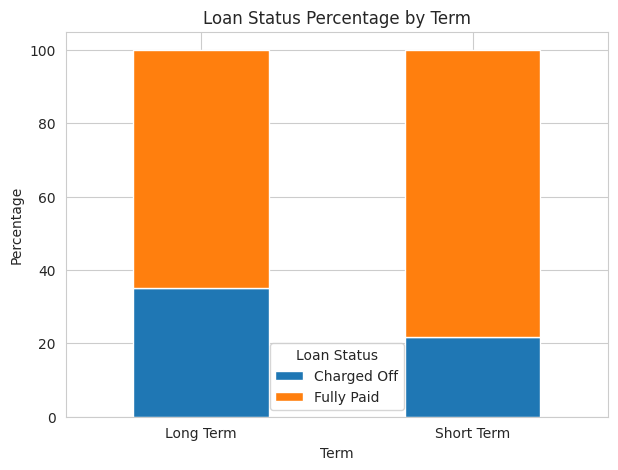

Loan Status,Charged Off,Fully Paid
Term,,
Long Term,35.21,64.79
Short Term,21.62,78.38


In [78]:
term_status = pd.crosstab(
    df_clean['Term'],
    df_clean['Loan Status'],
    normalize='index'
) * 100

term_status.plot(kind='bar', stacked=True, figsize=(7, 5))
plt.title('Loan Status Percentage by Term')
plt.ylabel('Percentage')
plt.xlabel('Term')
plt.xticks(rotation=0)
plt.show()

term_status.round(2)

**Insight:** Long-term loans show a noticeably higher charge-off rate than short-term loans. This is one of the strongest findings and suggests that longer repayment periods are associated with higher credit risk.

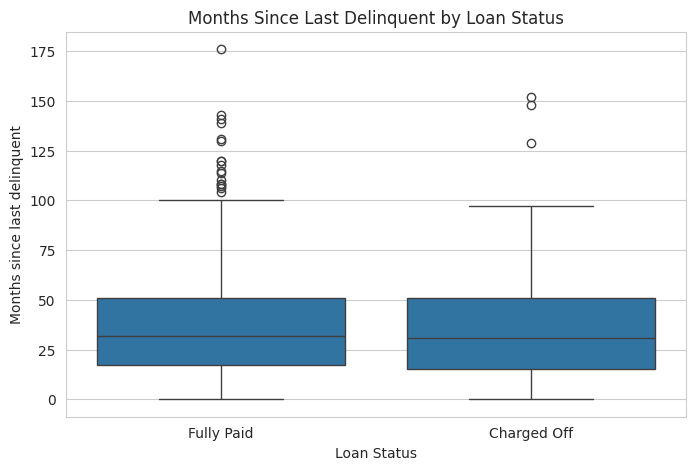

In [79]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_clean, x='Loan Status', y='Months since last delinquent')
plt.title('Months Since Last Delinquent by Loan Status')
plt.show()

**Insight:** Among borrowers with recorded delinquency history, the timing of last delinquency shows only modest variation between repayment outcomes. Missing values were intentionally preserved and should be interpreted separately as likely no recorded delinquency history.

## 10. Correlation Analysis
A correlation heatmap is used to examine relationships among numerical variables.

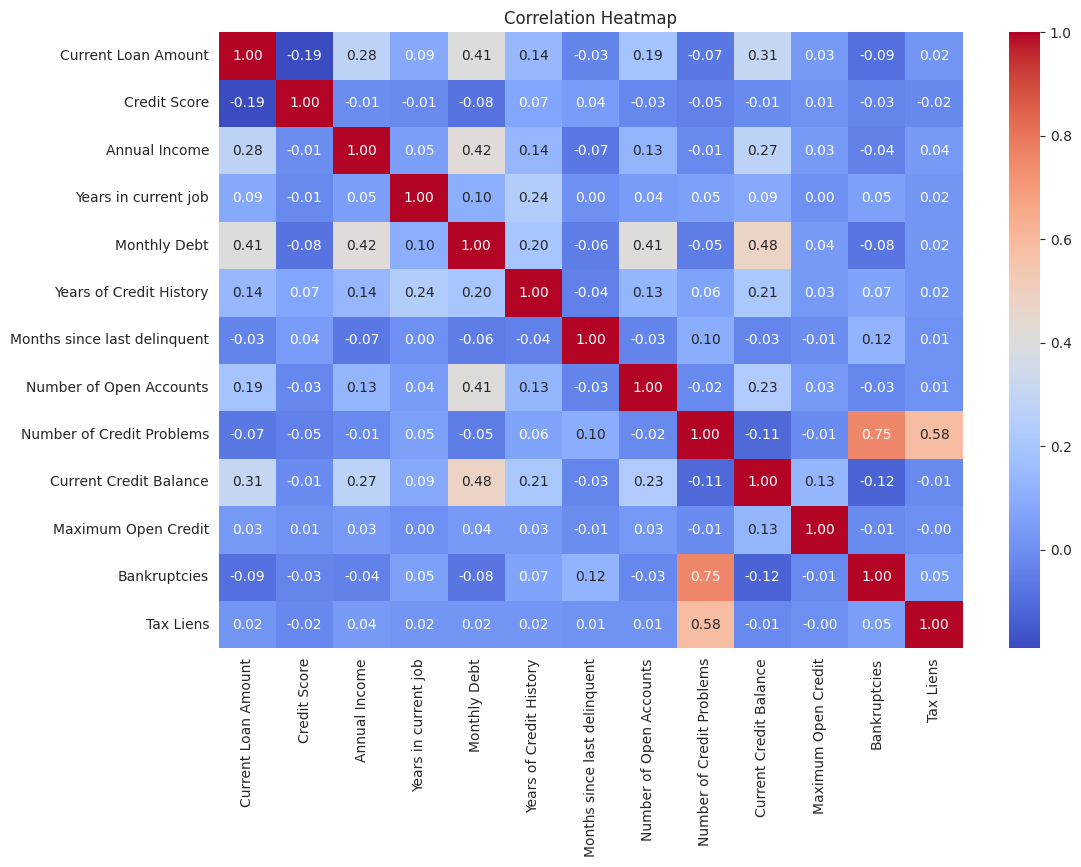

In [80]:
plt.figure(figsize=(12, 8))

corr = df_clean.select_dtypes(include=np.number).corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')

plt.title('Correlation Heatmap')
plt.show()

**Insight:** Strong relationships appear between credit problems and bankruptcies, and between credit problems and tax liens. Monthly debt also has moderate positive relationships with current credit balance, annual income, and current loan amount. These relationships suggest that financial risk is multidimensional rather than driven by one single feature.

## 11. Feature Engineering: Debt-to-Income Ratio
Debt-to-Income Ratio (DTI) is created as a borrower financial pressure indicator. It compares annualized monthly debt with annual income.

\[
DTI =
rac{Monthly\ Debt 	imes 12}{Annual\ Income}
\]

In [81]:
df_clean['Debt_to_Income_Ratio'] = (
    df_clean['Monthly Debt'] * 12
) / df_clean['Annual Income']

df_clean['Debt_to_Income_Ratio'].describe()

,Debt_to_Income_Ratio
count,89785.000000
mean,0.175265
std,0.090892
min,0.000000
25%,0.110166
50%,0.167999
75%,0.230000
max,1.565600


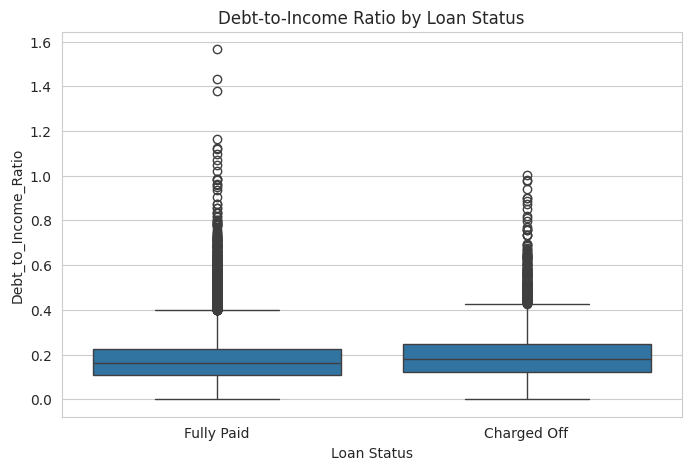

In [82]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_clean, x='Loan Status', y='Debt_to_Income_Ratio')
plt.title('Debt-to-Income Ratio by Loan Status')
plt.show()

**Insight:** Charged-off borrowers show a slightly higher DTI distribution and wider upper spread. This suggests that borrowers with higher debt obligations relative to income are more vulnerable to repayment difficulty.

## 12. Key Findings

1. **Most loans were fully paid**, but charge-offs still represent a meaningful share of the portfolio.
2. **Debt consolidation dominates borrowing behavior**, accounting for the majority of loan purposes.
3. **Long-term loans are riskier**, with a visibly higher charge-off percentage than short-term loans.
4. **Renters show slightly higher charge-off rates** than mortgage holders and homeowners.
5. **Higher credit scores are associated with successful repayment**, although the difference is moderate.
6. **Monthly debt and DTI are important financial stress indicators**, with charged-off borrowers showing higher debt burden patterns.
7. **Employment duration alone does not strongly separate repayment outcomes**.
8. **Credit problems, bankruptcies, and tax liens are strongly related**, indicating overlapping financial distress signals.
9. **Loan repayment appears multifactorial**, meaning no single variable fully explains charge-off behavior.

## 13. Business Recommendations

- Lenders should pay close attention to **loan term**, as long-term loans show higher charge-off risk.
- **Debt-to-income ratio** should be considered alongside credit score for borrower risk assessment.
- Borrowers applying for **debt consolidation** loans should be carefully evaluated because this purpose dominates the portfolio and may reflect existing financial pressure.
- Risk evaluation should use a combination of credit score, debt burden, loan term, and financial distress indicators rather than relying on one metric.

## 14. Conclusion

This EDA revealed important patterns in credit loan repayment behavior. While most borrowers successfully repay their loans, charge-off risk is meaningfully associated with longer loan terms, slightly lower credit scores, higher debt burden, and borrower financial stress indicators. The analysis also showed that some variables, such as employment duration, may have limited explanatory value on their own. Overall, loan repayment behavior is best understood through multiple interacting financial and borrower characteristics.

## 15. Save Cleaned Dataset
The cleaned dataset is saved for future analysis, dashboarding, or machine learning work.

In [83]:
# Save cleaned dataset
df_clean.to_csv('cleaned_credit_data.csv', index=False)
print('Cleaned dataset saved successfully!')

Cleaned dataset saved successfully!


In [84]:
import os

os.listdir()

['.config',
 'credit.csv',
 'credit (1).csv',
 'cleaned_credit_data.csv',
 'sample_data']

## Key Findings

1. Approximately 75% of borrowers successfully repaid loans, while around 25% resulted in charge-offs.

2. Long-term loans exhibited noticeably higher charge-off rates compared to short-term loans.

3. Debt consolidation represented the dominant loan purpose, accounting for the majority of borrowing behavior.

4. Borrowers with higher credit scores generally demonstrated stronger repayment performance.

5. Renters showed slightly elevated charge-off rates compared to mortgage holders and homeowners.

6. Higher debt-to-income ratios were associated with increased repayment difficulty.

7. Employment duration showed limited influence on loan repayment outcomes.

8. Financial distress indicators such as bankruptcies and credit problems exhibited strong correlation.

## Conclusion

This exploratory data analysis examined borrower financial behavior and factors associated with loan repayment outcomes.

The analysis revealed that repayment performance is influenced by multiple interacting factors rather than a single dominant variable. Loan duration, debt burden, creditworthiness, and financial distress indicators demonstrated meaningful relationships with loan outcomes.

Long-term loans and elevated debt-to-income ratios were associated with higher repayment risk, while stronger credit profiles generally corresponded with successful repayment.

Overall, this project demonstrates a complete end-to-end data analysis workflow, including data cleaning, preprocessing, exploratory analysis, feature engineering, and business insight extraction using Python.